In [62]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
def upload_data(ticker):
    try:
        data = yf.download(ticker, '2019-01-01', '2026-01-01')
    except Exception as e:
        print(f"this ticker information is unavailable", {e})
    else:
        return pd.DataFrame(data)

In [64]:
upload_data("SPY")

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2019-01-02,224.382507,225.306311,220.588691,220.615596,126925200
2019-01-03,219.028152,222.938569,218.543827,222.633618,144140700
2019-01-04,226.364670,227.010428,221.682932,222.059622,142628800
2019-01-07,228.149445,229.557546,225.736823,226.633708,103139100
2019-01-08,230.293045,230.777370,227.808685,230.337906,102512600
...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300


In [65]:
df = upload_data("SPY")

def plot_data(data):
    df["Close"].plot()
    plt.ylabel("Closing Price in USD$")
    plt.grid(True)
    plt.show()

[*********************100%***********************]  1 of 1 completed


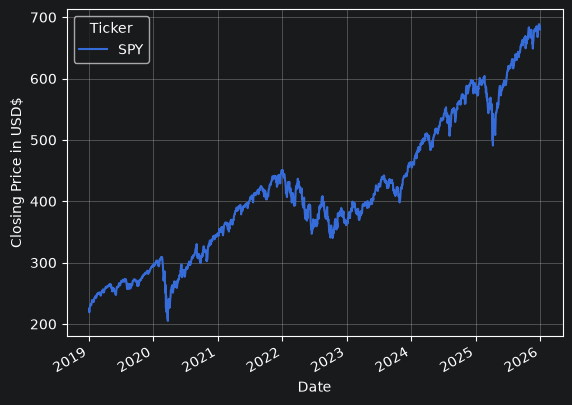

In [66]:
plot_data(df)

In [67]:
#calculate the moving average across a portion of the dataset

In [68]:
def three_day_moving_average_calculation(df):
    try:
        df["3MA"] = df.loc[:, "Close"].rolling(window=3).mean()
        return df
    except Exception as e:
        print(f"an error has occurred: {e}")
    finally:
        print("3 day moving average")

In [69]:
three_day_moving_average_calculation(df)

3 day moving average


Price,Close,High,Low,Open,Volume,3MA
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2019-01-02,224.382507,225.306311,220.588691,220.615596,126925200,NaN
2019-01-03,219.028152,222.938569,218.543827,222.633618,144140700,NaN
2019-01-04,226.364670,227.010428,221.682932,222.059622,142628800,223.258443
2019-01-07,228.149445,229.557546,225.736823,226.633708,103139100,224.514089
2019-01-08,230.293045,230.777370,227.808685,230.337906,102512600,228.269053
...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956


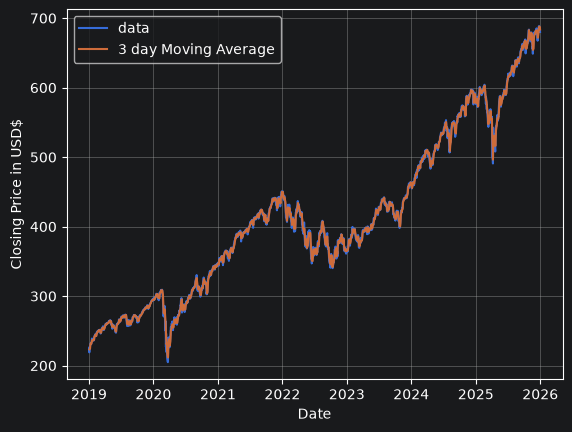

In [76]:
#plot the 3 day moving average
plt.plot(df["Close"], label="data")
plt.xlabel("Date")
plt.ylabel("Closing Price in USD$")
plt.plot(df["3MA"], label="3 day Moving Average")
plt.grid(True)
plt.legend(loc=2)
plt.show()

In [77]:
#calculate the 50-day moving average
def fifty_day_moving_average(df):
    try:
        df["50MA"] = df.loc[:, "Close"].rolling(window=50).mean()
        return df
    except Exception as e:
        print(f"an error has occurred:{e}")
    finally:
        print("50 day moving average")

In [78]:
fifty_day_moving_average(df)

50 day moving average


Price,Close,High,Low,Open,Volume,3MA,50MA
Ticker,SPY,SPY,SPY,SPY,SPY,,
Date,,,,,,,
2019-01-02,224.382507,225.306311,220.588691,220.615596,126925200,NaN,NaN
2019-01-03,219.028152,222.938569,218.543827,222.633618,144140700,NaN,NaN
2019-01-04,226.364670,227.010428,221.682932,222.059622,142628800,223.258443,NaN
2019-01-07,228.149445,229.557546,225.736823,226.633708,103139100,224.514089,NaN
2019-01-08,230.293045,230.777370,227.808685,230.337906,102512600,228.269053,NaN
...,...,...,...,...,...,...,...
2025-12-24,688.499695,688.948481,685.926705,686.076320,39445600,685.850281,673.116240
2025-12-26,688.429871,689.776169,687.392725,688.758989,41613300,687.671956,673.656758


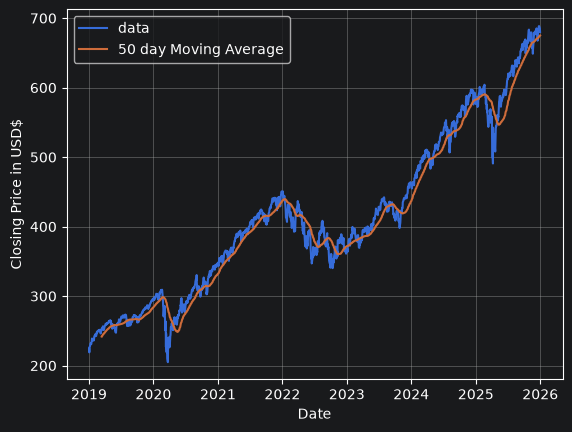

In [80]:
#50 day moving average
plt.plot(df["Close"], label="data")
plt.plot(df["50MA"], label="50 day Moving Average")
plt.xlabel("Date")
plt.ylabel("Closing Price in USD$")
plt.grid(True)
plt.legend(loc=2)
plt.show()

In [87]:
#plot the both the 3 day and 50 day moving average for the last 100 days of close price data
def moving_average_plots(df):
    df = df.iloc[-100:, :]
    plt.plot(df['Close'], label="Closing Price")
    plt.plot(df["3MA"],label="3 day moving average")
    plt.plot(df["50MA"], label="50 day moving average")
    plt.grid(True)
    plt.legend(loc=2)
    plt.show()

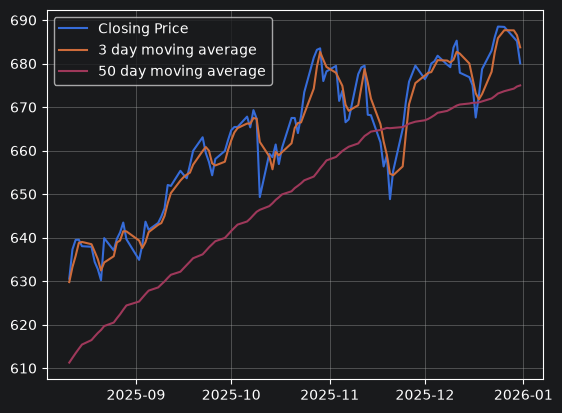

In [88]:
moving_average_plots(df)

In [ ]:
#formulate trading strategy